# 02 — Number distribution in the Pile & Pythia generations (Fig 1, Fig 4)

Reproduces **RQ1 (Fig 1)** and **RQ3 (Fig 4)** from the report.

**Fig 1** (Sec 3.1) — frequency of integers 1–100 in the Pile, power-law fit + culturally
significant exceptions (powers of 10 / multiples of 10; 5/15/25/12).

**Fig 4** (Sec 3.3) — Pythia-12B-deduped "list of random numbers" task: the model is
prompted to produce a list of random numbers between 1 and 100 (5,000 generations, pooled
into ~48k individual numbers). Plot the resulting frequency distribution and the same
power-law fit.

**Inputs:**

- `data/pile_number_distribution.json` — produced by `01_corpus_scan.ipynb`.
- `data/generations_multi.csv` — "list of random numbers" generations from Pythia-12B-deduped.

**Outputs:** figures saved to `../results/figures/`.

Source logic was migrated from the legacy `number.ipynb` (now in `notebooks/99_archive/`).
The model-loading and live-generation cells were replaced with reload-from-CSV, since the
precomputed outputs are checked in under `data/`.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

FIG_DIR = "../results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Cached aggregates from the Pile scan
with open("../data/pile_number_distribution.json") as f:
    pile = json.load(f)

small = pile["small_value_counts"]   # str -> int, |x| <= 10000
pile_counts = pd.Series({int(k): v for k, v in small.items()}).sort_index()
print(f"Pile integers tracked: {pile['total_numbers']:,}")
print(f"Distinct values stored: {len(pile_counts)}")

Pile integers tracked: 4,776,629,260
Distinct values stored: 19578


## Fig 1 — Numbers 1–100 in the Pile

(left) count of each integer 1–100 in the Pile.
(right) log-log plot with power-law fit and culturally-significant numbers highlighted.

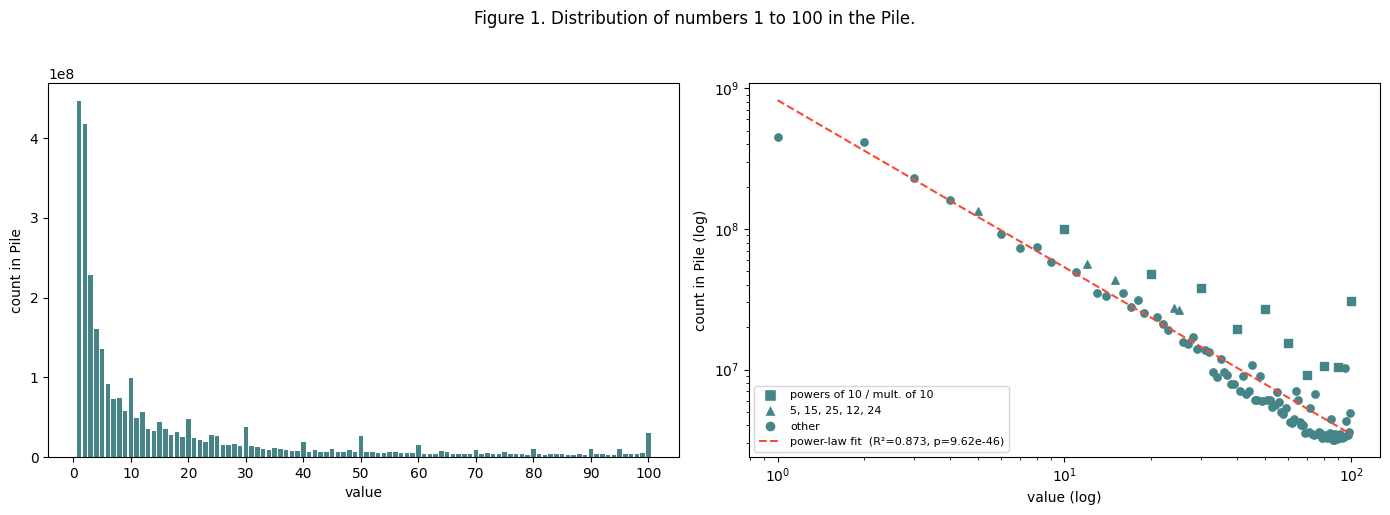

R² = 0.8732,  p = 9.62e-46    (report quotes R²=0.87, p=9.62e-46)


In [2]:
# Pull 1..100 from the cached counts
vals  = np.arange(1, 101)
counts = pile_counts.reindex(vals, fill_value=0).values

POW10   = {10, 100, 1000}
MULT10  = {20, 30, 40, 50, 60, 70, 80, 90}
MULT5_15_25 = {5, 15, 25}
IDIO    = {12, 24}

def shape_for(v):
    if v in POW10 or v in MULT10: return "s"   # square
    if v in MULT5_15_25 or v in IDIO: return "^" # triangle
    return "o"

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear count bar chart (no legend)
ax_lin.bar(vals, counts, color="#458588")
ax_lin.set_xlabel("value")
ax_lin.set_ylabel("count in Pile")
ax_lin.set_xticks(np.arange(0, 101, 10))

# Right: log-log with shapes for culturally significant numbers
for v in vals:
    ax_log.scatter(v, counts[v - 1], marker=shape_for(v),
                    c="#458588", s=28,
                    label=("powers of 10 / mult. of 10" if v == 10 and False else None))
# Fit a power law on log-log (drop zeros)
mask = counts > 0
logx = np.log10(vals[mask].astype(float))
logy = np.log10(counts[mask].astype(float))
slope, intercept, r, p, se = stats.linregress(logx, logy)
xfit = np.linspace(vals.min(), vals.max(), 200)
yfit = 10 ** (intercept + slope * np.log10(xfit))
ax_log.plot(xfit, yfit, "--", color="#fb4934", lw=1.5,
             label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})")
ax_log.set_xscale("log")
ax_log.set_yscale("log")
ax_log.set_xlabel("value (log)")
ax_log.set_ylabel("count in Pile (log)")

# Build a clean legend with three entries (square, triangle, fit)
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#458588",
           markersize=8, label="powers of 10 / mult. of 10"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#458588",
           markersize=8, label="5, 15, 25, 12, 24"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#458588",
           markersize=8, label="other"),
    Line2D([0], [0], linestyle="--", color="#fb4934",
           label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})"),
]
ax_log.legend(handles=handles, fontsize=8, loc="lower left")

fig.suptitle("Figure 1. Distribution of numbers 1 to 100 in the Pile.", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_numbers_1_100.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"R² = {r**2:.4f},  p = {p:.2e}    (report quotes R²=0.87, p=9.62e-46)")

## Fig 4 — Pythia-12B number production task

The report's Fig 4 is built from the "list of random numbers" prompt
(`data/generations_multi.csv`): each of 5,000 generations is parsed into its component
numbers (pipe-separated in the `numbers` column), pooled into one distribution, and fit
with the same power-law/shape conventions as Fig 1.

List-of-numbers generations: 5000 rows
Parsed 48108 numbers in [1, 100].


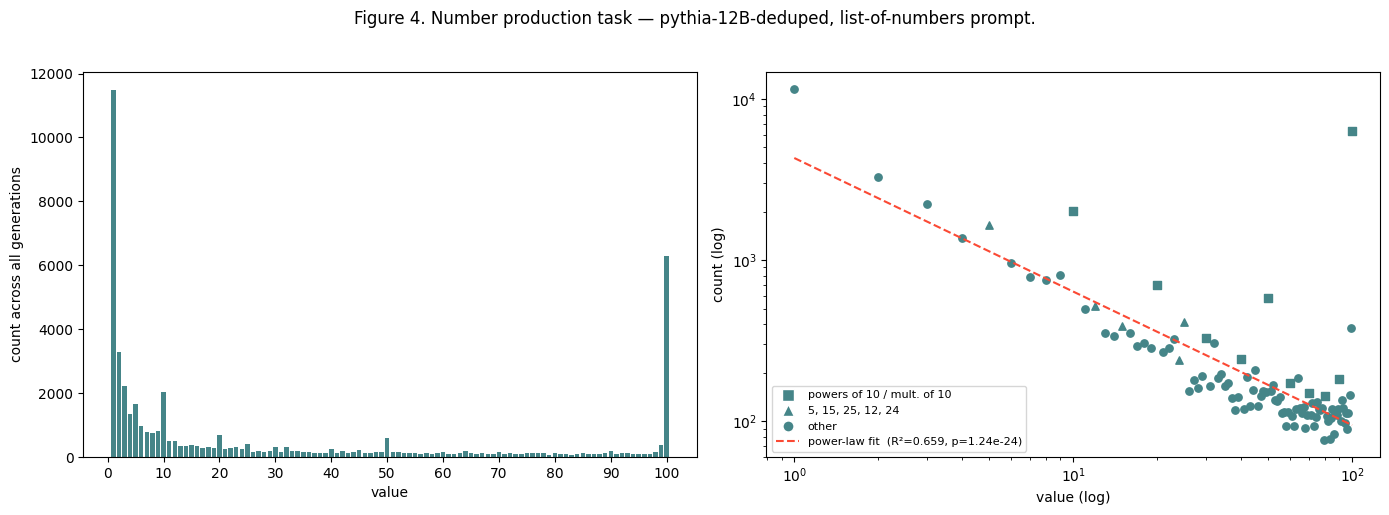

1-100:  r = -0.8118,  R² = 0.6591,  p = 1.241e-24    (report quotes R²=0.66)
2-99 :  r = -0.9010,  R² = 0.8118,  p = 1.375e-36    (report quotes R²=0.812)


In [3]:
# Load "list of numbers" generations — this is what the report's Fig 4 is built from.
multi = pd.read_csv("../data/generations_multi.csv")
print(f"List-of-numbers generations: {len(multi)} rows")

# `numbers` is a pipe-separated string of parsed values per generation, e.g. "1|100|3".
multi_nums = []
for s in multi["numbers"].dropna():
    multi_nums.extend(int(x) for x in str(s).split("|") if 1 <= int(x) <= 100)
print(f"Parsed {len(multi_nums)} numbers in [1, 100].")

mc = pd.Series(multi_nums).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
vals = np.arange(1, 101)
counts = mc.values

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear count bar chart
ax_lin.bar(vals, counts, color="#458588")
ax_lin.set_xlabel("value")
ax_lin.set_ylabel("count across all generations")
ax_lin.set_xticks(np.arange(0, 101, 10))

# Right: log-log with shapes for culturally significant numbers
for v in vals:
    ax_log.scatter(v, counts[v - 1], marker=shape_for(v),
                    c="#458588", s=28)

# Fit a power law on log-log (drop zeros)
mask = counts > 0
logx = np.log10(vals[mask].astype(float))
logy = np.log10(counts[mask].astype(float))
slope, intercept, r, p, se = stats.linregress(logx, logy)
xfit = np.linspace(vals.min(), vals.max(), 200)
yfit = 10 ** (intercept + slope * np.log10(xfit))
ax_log.plot(xfit, yfit, "--", color="#fb4934", lw=1.5,
             label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})")
ax_log.set_xscale("log")
ax_log.set_yscale("log")
ax_log.set_xlabel("value (log)")
ax_log.set_ylabel("count (log)")

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#458588",
           markersize=8, label="powers of 10 / mult. of 10"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#458588",
           markersize=8, label="5, 15, 25, 12, 24"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#458588",
           markersize=8, label="other"),
    Line2D([0], [0], linestyle="--", color="#fb4934",
           label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})"),
]
ax_log.legend(handles=handles, fontsize=8, loc="lower left")

fig.suptitle("Figure 4. Number production task — pythia-12B-deduped, list-of-numbers prompt.", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_number_production.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"1-100:  r = {r:.4f},  R² = {r**2:.4f},  p = {p:.3e}    (report quotes R²=0.66)")

# Refit excluding 1 and 100 (report quotes R²=0.812)
mask2 = (counts > 0) & (vals >= 2) & (vals <= 99)
logx2 = np.log10(vals[mask2].astype(float))
logy2 = np.log10(counts[mask2].astype(float))
slope2, intercept2, r2, p2, se2 = stats.linregress(logx2, logy2)
print(f"2-99 :  r = {r2:.4f},  R² = {r2**2:.4f},  p = {p2:.3e}    (report quotes R²=0.812)")

## Supplementary — Number production task, 1–1000 (extending Fig 4)

Noma & Baird (1975) reported the same power-function pattern for random-number generation
in the range 1–1000, not just 1–100. To check whether this generalizes, we repeat the
"list of random numbers" task with the prompt range extended to 1–1000 (pythia-12B-deduped,
1,000 generations, same sampling settings as Fig 4:
`"Question: Generate a list of random numbers between 1 and 1000.\nAnswer:"`, T=1.0,
top-k/top-p disabled).

List-of-numbers (1-1000) generations: 1000 rows
Parsed 10023 numbers in [1, 1000].


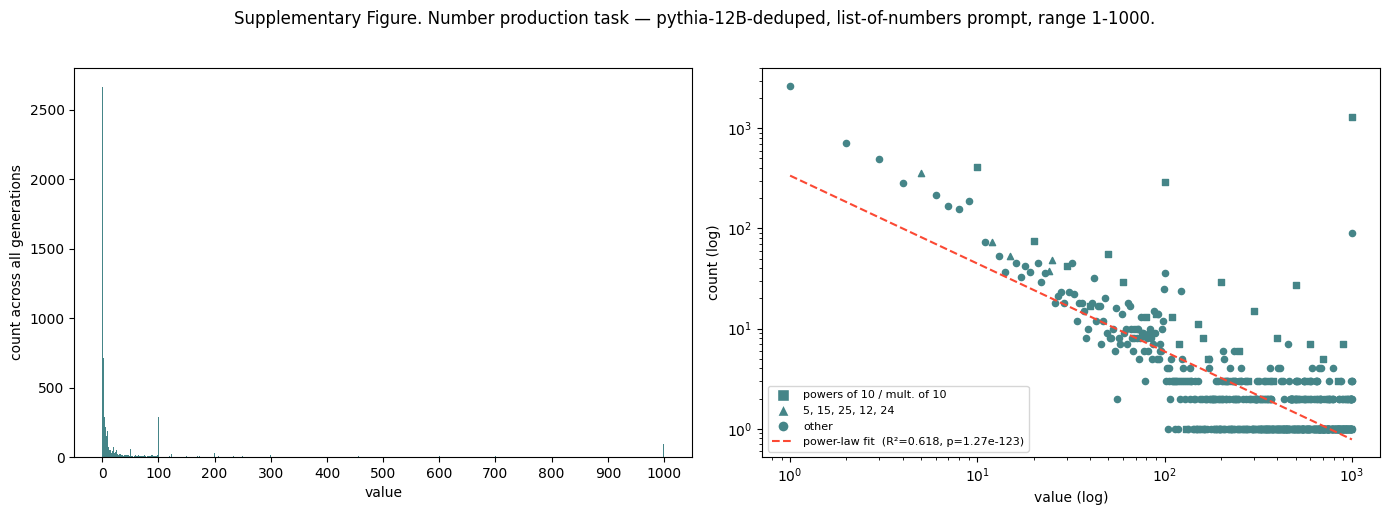

1-1000:  r = -0.7863,  R² = 0.6183,  p = 1.265e-123
2-999 :  r = -0.8054,  R² = 0.6487,  p = 1.216e-133


In [4]:
# Supplementary — "list of random numbers between 1 and 1000" prompt, pythia-12B-deduped
multi_1000 = pd.read_csv("../data/generations_multi_1_1000.csv")
print(f"List-of-numbers (1-1000) generations: {len(multi_1000)} rows")

multi_1000_nums = []
for s in multi_1000["numbers"].dropna():
    multi_1000_nums.extend(int(x) for x in str(s).split("|") if 1 <= int(x) <= 1000)
print(f"Parsed {len(multi_1000_nums)} numbers in [1, 1000].")

mc1000 = pd.Series(multi_1000_nums).value_counts().reindex(range(1, 1001), fill_value=0).sort_index()
vals1000 = np.arange(1, 1001)
counts1000 = mc1000.values

POW10_1000 = {10, 100, 1000}
MULT10_1000 = set(range(10, 1000, 10)) - POW10_1000

def shape_for_1000(v):
    if v in POW10_1000 or v in MULT10_1000: return "s"
    if v in MULT5_15_25 or v in IDIO: return "^"
    return "o"

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

ax_lin.bar(vals1000, counts1000, color="#458588", width=1.0)
ax_lin.set_xlabel("value")
ax_lin.set_ylabel("count across all generations")
ax_lin.set_xticks(np.arange(0, 1001, 100))

for v in vals1000:
    ax_log.scatter(v, counts1000[v - 1], marker=shape_for_1000(v), c="#458588", s=20)

mask = counts1000 > 0
logx = np.log10(vals1000[mask].astype(float))
logy = np.log10(counts1000[mask].astype(float))
slope, intercept, r, p, se = stats.linregress(logx, logy)
xfit = np.linspace(vals1000.min(), vals1000.max(), 200)
yfit = 10 ** (intercept + slope * np.log10(xfit))
ax_log.plot(xfit, yfit, "--", color="#fb4934", lw=1.5,
             label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})")
ax_log.set_xscale("log")
ax_log.set_yscale("log")
ax_log.set_xlabel("value (log)")
ax_log.set_ylabel("count (log)")

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#458588",
           markersize=8, label="powers of 10 / mult. of 10"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#458588",
           markersize=8, label="5, 15, 25, 12, 24"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#458588",
           markersize=8, label="other"),
    Line2D([0], [0], linestyle="--", color="#fb4934",
           label=f"power-law fit  (R²={r**2:.3f}, p={p:.2e})"),
]
ax_log.legend(handles=handles, fontsize=8, loc="lower left")

fig.suptitle("Supplementary Figure. Number production task — pythia-12B-deduped, list-of-numbers prompt, range 1-1000.", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/supp_fig_number_production_1_1000.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"1-1000:  r = {r:.4f},  R² = {r**2:.4f},  p = {p:.3e}")

# Refit excluding endpoints 1 and 1000 (same rationale as the 1-100 Fig 4 refit)
mask2 = (counts1000 > 0) & (vals1000 >= 2) & (vals1000 <= 999)
logx2 = np.log10(vals1000[mask2].astype(float))
logy2 = np.log10(counts1000[mask2].astype(float))
slope2, intercept2, r2, p2, se2 = stats.linregress(logx2, logy2)
print(f"2-999 :  r = {r2:.4f},  R² = {r2**2:.4f},  p = {p2:.3e}")


## Take-aways (matching the report text)

- Fig 1: Pile numbers 1–100 follow a power function of size (R²≈0.87) with frequency
  spikes at powers of 10, multiples of 5 (15, 25), and 12/24 (Sec 3.1).
- Fig 4: Pythia-12B-deduped's "list of random numbers" generations also follow a power
  function (R²≈0.66 for full 1–100, R²≈0.812 for 2–99). Powers of 10 / multiples of 10
  are over-represented; the other culturally-significant numbers (12, 15, 25) are not
  (Sec 3.3).

All figures are saved into `../results/figures/`.
Open `notebooks/04_arithmetic_main.ipynb` for Fig 2 / Fig 3 / Fig 5 / Fig 6 / Sec 3.5.